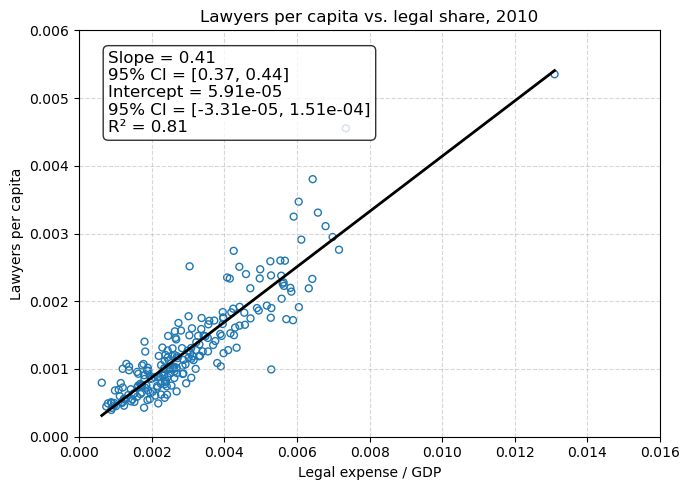

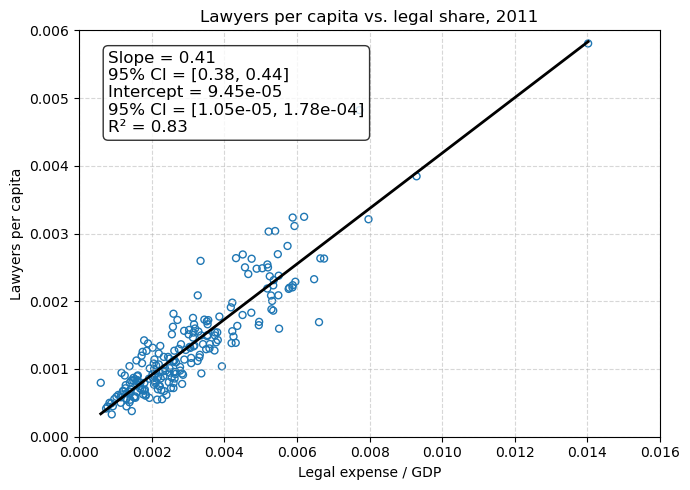

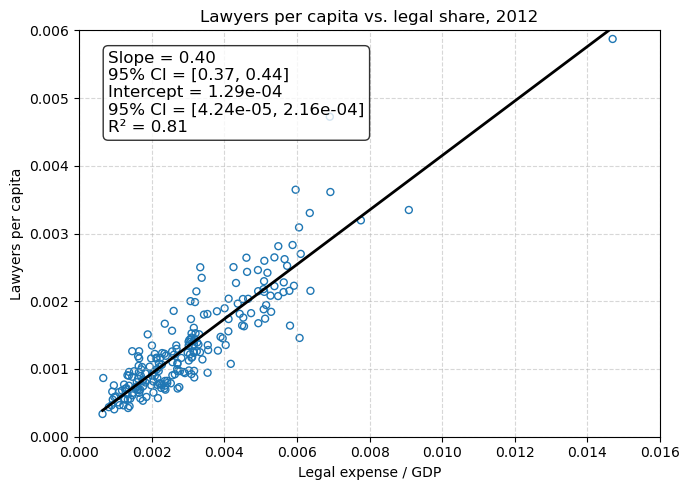

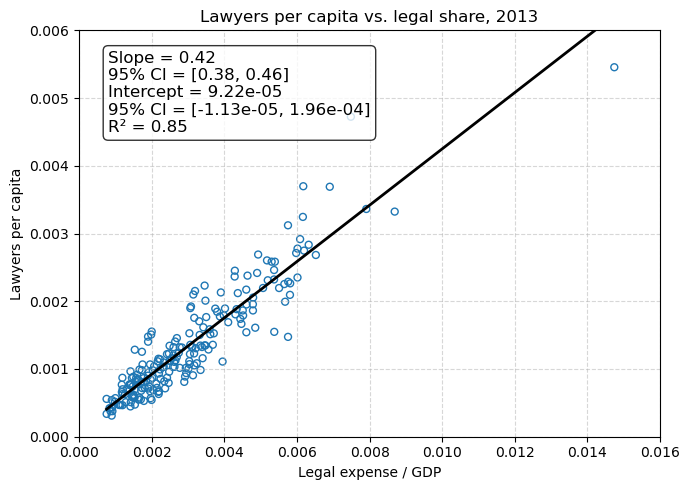

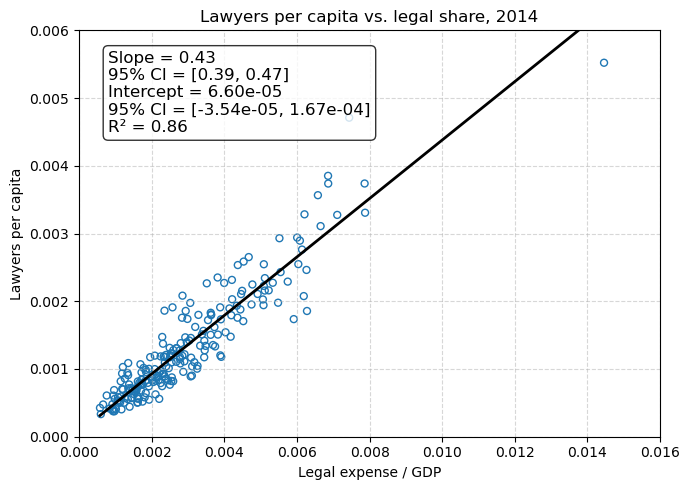

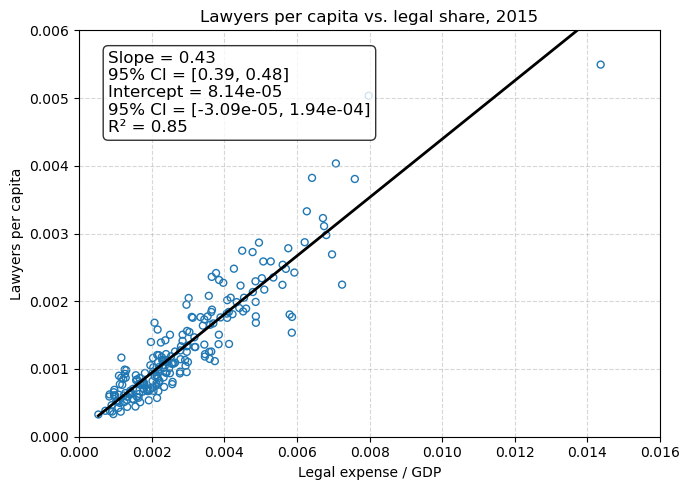

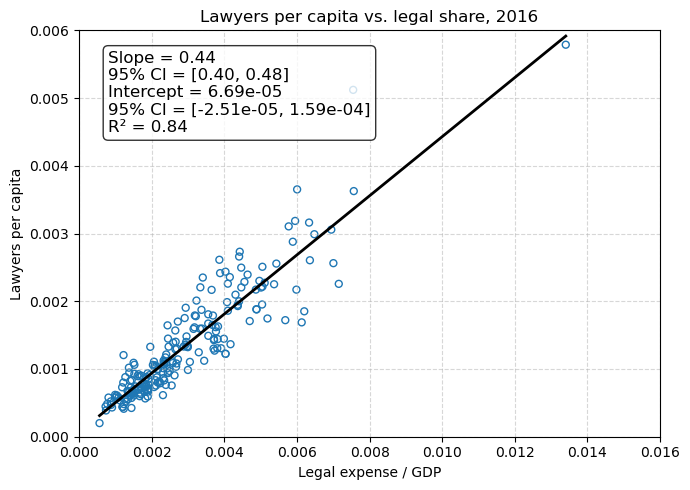

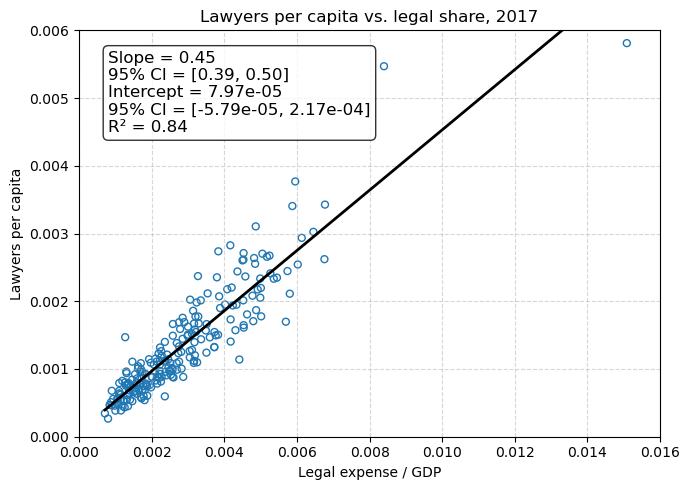

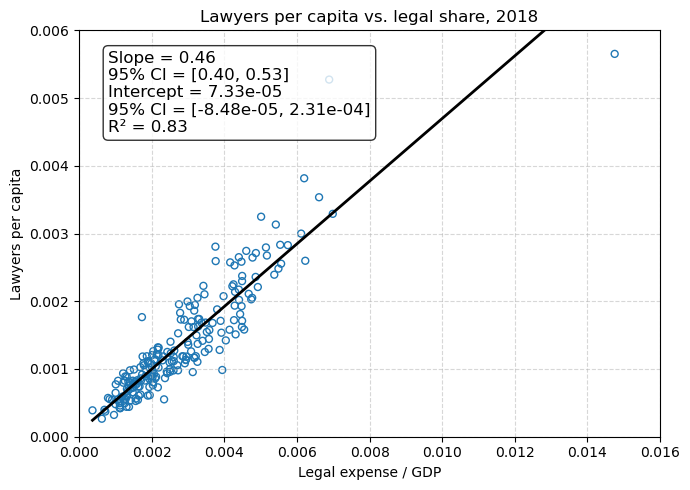

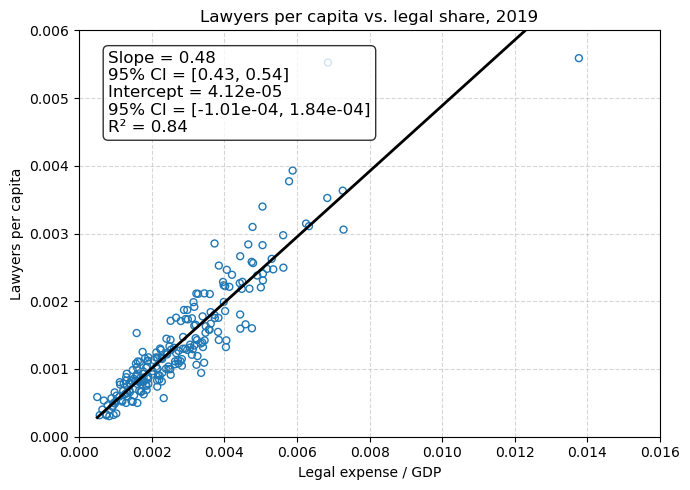

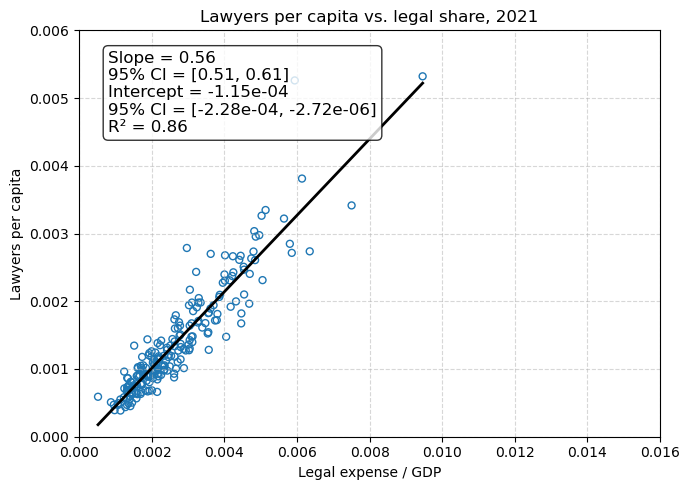

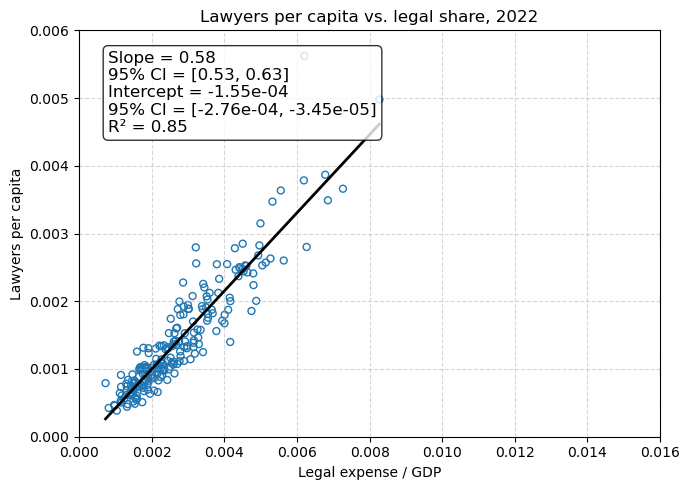

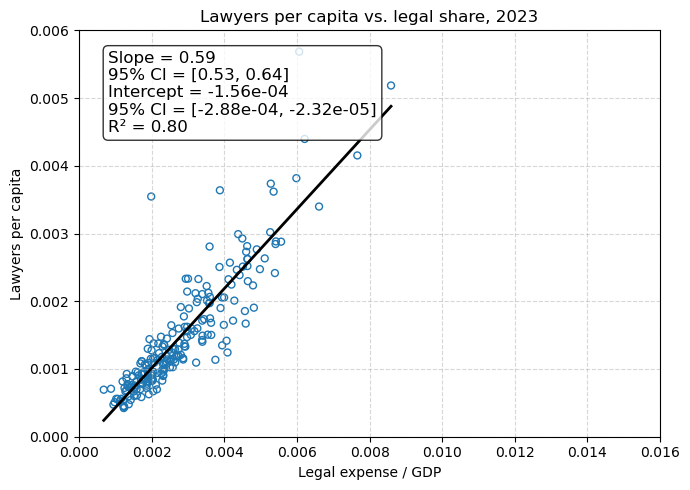

In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path

current_path = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [current_path, *current_path.parents] if (p / "Scripts").is_dir()), None)

if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from within the repository.")

data_path = PROJECT_ROOT / "Data/Processed Data/Legal-Economy-Coupling/Legal_Economy_Data.csv"
results_dir = PROJECT_ROOT / "Data/Processed Data/Legal-Economy-Coupling"
results_dir.mkdir(parents=True, exist_ok=True)

# Load data
df = pd.read_csv(data_path)

# Theory
df["gdp_per_cap"] = df["GDP"] / df["Population"]    # GDP per ccapita
df["A_mean_to_gdp_per_cap"] = df["A_MEAN"] / df["gdp_per_cap"]  # Mean lawyer salary to GDP per capita

# Scaling over time
variables = ['Legal_Expense', 'GDP', 'Num_Lawyers']
results_list = []

for year in sorted(df['year'].unique()):
    df_year = df[df['year'] == year].copy()

    for var in variables:
        df_year = df_year[(df_year['Population'] > 0) & (df_year[var] > 0)]
        X = sm.add_constant(np.log10(df_year['Population']))
        y = np.log10(df_year[var])
        model = sm.OLS(y, X).fit(cov_type='HC1')

        slope = model.params.iloc[1]        # Power-law exponent β
        prefactor = 10 ** model.params.iloc[0]  # Prefactor α
        ci_lower, ci_upper = model.conf_int().iloc[1]
        r2 = model.rsquared

        results_list.append({
            'year': year,
            'variable': var,
            'prefactor': prefactor,
            'slope': slope,
            'CI_lower': ci_lower,
            'CI_upper': ci_upper,
            'R2': r2
        })

scaling_table = pd.DataFrame(results_list)
save = 0    # Save the scaling values
if save:
    scaling_table.to_csv("Data/Processed Data/Figuresscaling_table.csv", index=False)

# Annual scaling plots
plot = 0    # Plot annual scaling
if plot:
    for year in sorted(df['year'].unique()):
        df_year = df[df['year'] == year].copy()

        for var in variables:
            df_year = df_year[(df_year['Population'] > 0) & (df_year[var] > 0)]
            X = sm.add_constant(np.log10(df_year['Population']))
            y = np.log10(df_year[var])
            model = sm.OLS(y, X).fit(cov_type='HC1')

            slope = model.params.iloc[1]
            prefactor = 10 ** model.params.iloc[0]
            ci_lower, ci_upper = model.conf_int().iloc[1]
            r2 = model.rsquared

            # Plot log-log data
            plt.figure(figsize=(7, 5))
            plt.scatter(df_year['Population'], df_year[var], alpha=0.6, edgecolor='k', s=50)
            x_range = np.linspace(df_year['Population'].min(), df_year['Population'].max(), 100)
            y_pred = prefactor * (x_range ** slope)
            plt.plot(x_range, y_pred, color='red', linewidth=2, label='Power-law fit')

            plt.xscale('log')
            plt.yscale('log')
            plt.xlabel('Population')
            plt.ylabel(var)
            plt.title(f'{var} vs Population, {year}')

            plt.text(0.05, 0.95,
                     f"Slope = {slope:.2f}\n95% CI = [{ci_lower:.2f}, {ci_upper:.2f}]\nR² = {r2:.2f}",
                     transform=plt.gca().transAxes,
                     fontsize=12,
                     verticalalignment='top',
                     bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

            plt.grid(True, linestyle='--', alpha=0.5)
            plt.legend()
            plt.tight_layout()
            plt.show()

# Plotting lawyers per capita vs. legal expenses/GDP
save = 0
fit_results = []

for year in sorted(df['year'].unique()):
    df_year = df[df['year'] == year].copy()

    # Drop zeros
    df_year = df_year[
        (df_year['legal_per_gdp'] > 0) &
        (df_year['lawyers_per_cap'] > 0)
    ]

    X = sm.add_constant(df_year['legal_per_gdp'])
    y = df_year['lawyers_per_cap']
    model = sm.OLS(y, X).fit(cov_type='HC1')

    slope = model.params.iloc[1]
    intercept = model.params.iloc[0]
    ci_lower_slope, ci_upper_slope = model.conf_int().iloc[1]
    ci_lower_intercept, ci_upper_intercept = model.conf_int().iloc[0]
    r2 = model.rsquared

    fit_results.append({
        "year": year,
        "x_var": "legal_per_gdp",
        "y_var": "lawyers_per_cap",
        "slope": slope,
        "intercept": intercept,
        "slope_ci_lower": ci_lower_slope,
        "slope_ci_upper": ci_upper_slope,
        "intercept_ci_lower": ci_lower_intercept,
        "intercept_ci_upper": ci_upper_intercept,
        "r2": r2,
        "n": len(X)
    })

    plt.figure(figsize=(7, 5))

    plt.scatter(
        df_year['legal_per_gdp'],
        df_year['lawyers_per_cap'],
        facecolors='none',
        edgecolor='#1f77b4',
        s=25
    )

    x_range = np.linspace(
        df_year['legal_per_gdp'].min(),
        df_year['legal_per_gdp'].max(),
        100
    )

    y_pred = intercept + x_range * slope
    plt.plot(x_range, y_pred, color='black', linewidth=2)

    # Swapped from the old limits
    plt.xlim(0, 0.016)
    plt.ylim(0, 0.006)

    plt.xlabel('Legal expense / GDP')
    plt.ylabel('Lawyers per capita')
    plt.title(f'Lawyers per capita vs. legal share, {year}')

    plt.text(
        0.05, 0.95,
        f"Slope = {slope:.2f}\n"
        f"95% CI = [{ci_lower_slope:.2f}, {ci_upper_slope:.2f}]\n"
        f"Intercept = {intercept:.2e}\n"
        f"95% CI = [{ci_lower_intercept:.2e}, {ci_upper_intercept:.2e}]\n"
        f"R² = {r2:.2f}",
        transform=plt.gca().transAxes,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
    )

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

    if save:
        plt.savefig(f"Figures/Affordability/legal_share_{year}.pdf", format="pdf", bbox_inches="tight")

    plt.show()

fit_df = pd.DataFrame(fit_results)
save_dir = PROJECT_ROOT / "Data/Processed Data/Legal-Economy-Coupling/"
save_dir.mkdir(parents=True, exist_ok=True)
fit_df.to_csv(save_dir/"Legal_Economy_Results.csv", index=False)